# 03 — Swin-Tiny baseline
This is an 11-class, single-label experiment using the cleaned CSV and original train/val/test splits.
Train the new classifier for 2 epochs at 5e-4, then fine-tune the whole model for 13 epochs at 5e-5.
Run the cells in order. Every epoch uses validation macro F1 for checkpoint selection; evaluate test after training finishes.


## 1. Imports

Use plain PyTorch, the official torchvision model, and scikit-learn metrics. The preprocessing stays in PIL and PyTorch, as in notebook 02. Use a compatible PyTorch/torchvision pair in your notebook kernel.


In [1]:
from pathlib import Path
import json
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image, ImageEnhance
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
import torchvision
from torchvision.models import swin_t, Swin_T_Weights
from sklearn.metrics import (
    accuracy_score, precision_recall_fscore_support,
    classification_report, confusion_matrix,
)

print("PyTorch:", torch.__version__, "| torchvision:", torchvision.__version__)


PyTorch: 2.12.1+cu126 | torchvision: 0.27.1+cu126


## 2. Paths, settings and seeds

Set PROJECT to the folder containing DATASET when using Colab or another working directory. Metadata paths already start with DATASET/, so resolve them from the project root. NUM_WORKERS=0 keeps the notebook simple on Windows; CPU fallback works but full training will be slower.


In [2]:
PROJECT = Path.cwd()  # Change this to your project location if needed.
ROOT = PROJECT
CLEANED_CSV = PROJECT / "DATASET" / "cleaned_top11_metadata.csv"
CHECKPOINT_PATH = PROJECT / "best_swin_tiny.pth"
HISTORY_PATH = PROJECT / "swin_tiny_history.csv"
METRICS_PATH = PROJECT / "swin_tiny_metrics.json"
WEIGHTS_CACHE = PROJECT / ".torch_cache"
torch.hub.set_dir(str(WEIGHTS_CACHE))  # Reuse the downloaded weights on later runs.

SEED = 42
BATCH_SIZE = 16
NUM_WORKERS = 0
NUM_EPOCHS = 15
HEAD_EPOCHS = 2
HEAD_LR = 5e-4
FINE_TUNE_LR = 5e-5
WEIGHT_DECAY = 1e-4
assert 0 < HEAD_EPOCHS < NUM_EPOCHS

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
use_amp = device.type == "cuda"
print("Device:", device, "| CUDA mixed precision:", use_amp)
if use_amp:
    print("GPU:", torch.cuda.get_device_name(0))
print("Metadata:", CLEANED_CSV)
print(f"Head: {HEAD_EPOCHS} epochs at {HEAD_LR}; full fine-tuning: {NUM_EPOCHS - HEAD_EPOCHS} epochs at {FINE_TUNE_LR}")


Device: cuda | CUDA mixed precision: True
GPU: NVIDIA GeForce RTX 3050 6GB Laptop GPU
Metadata: c:\Users\aravi\OneDrive\Desktop\coding\FYP MR disease classification\DATASET\cleaned_top11_metadata.csv
Head: 2 epochs at 0.0005; full fine-tuning: 13 epochs at 5e-05


## 3. Load metadata and class mapping

Read the cleaned metadata without repeating cleaning or hashing. The model uses Target; keep Class_Index as the original disease index. Print actual counts and compare them with the expected dataset sizes.


In [3]:
assert CLEANED_CSV.is_file(), f"Missing {CLEANED_CSV}. Check PROJECT or run notebook 01."
df = pd.read_csv(CLEANED_CSV, dtype={"Image_ID": "string", "Class_Index": "string"})
assert set(df["Split"]) == {"train", "val", "test"}
assert df["Target"].notna().all() and df["Target"].mod(1).eq(0).all()
df["Target"] = df["Target"].astype("int64")
assert set(df["Target"]) == set(range(11))
assert df.groupby("Disease")["Target"].nunique().eq(1).all()
assert df.groupby("Target")["Disease"].nunique().eq(1).all()
assert not df.duplicated(["Split", "Image_ID"]).any()

class_table = df[["Target", "Disease", "Class_Index"]].drop_duplicates().sort_values("Target").reset_index(drop=True)
class_table["Class_Index"] = class_table["Class_Index"].astype(int)
assert len(class_table) == 11
class_names = class_table["Disease"].tolist()
TARGET_MAP = dict(zip(class_table["Disease"], class_table["Target"].astype(int)))
num_classes = len(class_names)
LABELS = list(range(num_classes))
counts = df["Split"].value_counts().reindex(["train", "val", "test"], fill_value=0)
expected = pd.Series({"train": 911, "val": 278, "test": 304})
display(pd.DataFrame({"actual": counts, "expected": expected, "difference": counts - expected}))
print("Total:", len(df), "| classes:", num_classes)
print("Class-to-target mapping:", TARGET_MAP)
display(class_table)
display(pd.crosstab(df["Disease"], df["Split"]).reindex(class_names))


,actual,expected,difference
train,911,911,0
val,278,278,0
test,304,304,0


Total: 1493 | classes: 11
Class-to-target mapping: {'DR': 0, 'MH': 1, 'ODC': 2, 'DN': 3, 'BRVO': 4, 'ODE': 5, 'MYA': 6, 'ARMD': 7, 'RS': 8, 'CSR': 9, 'CRVO': 10}


,Target,Disease,Class_Index
0,0,DR,0
1,1,MH,2
2,2,ODC,11
3,3,DN,3
4,4,BRVO,5
5,5,ODE,16
6,6,MYA,4
7,7,ARMD,1
8,8,RS,13
9,9,CSR,10


Split,test,train,val
Disease,,,
DR,80,240,81
MH,73,180,62
ODC,18,119,18
DN,30,89,33
BRVO,18,54,10
ODE,15,52,14
MYA,17,46,12
ARMD,18,34,17
RS,14,39,14


## 4. Reuse image-path resolution

This is the path resolver from notebook 02 with ROOT set to the current project folder. Check that every selected image exists; do not rerun SHA-256 or the full image-quality audit here.


In [4]:
def resolve_image_path(row):
    for column in ["Image_Path", "Output_Path", "Resolved_Source_Path", "Source_Path"]:
        value = row.get(column)
        if pd.isna(value) or not str(value).strip():
            continue
        path = Path(str(value))
        choices = [path] if path.is_absolute() else [ROOT / path, PROJECT / path]
        for choice in choices:
            if choice.is_file():
                return choice
    fallback = ROOT / "DATASET" / str(row["Split"]) / f"Class_{row['Class_Index']}_{row['Disease']}" / f"{row['Image_ID']}.png"
    if fallback.is_file():
        return fallback
    raise FileNotFoundError(f"No image for {row['Split']} / {row['Image_ID']}")

resolved_paths = [resolve_image_path(row) for _, row in df.iterrows()]
print("Resolved images:", len(resolved_paths), "| first path:", resolved_paths[0])


Resolved images: 1493 | first path: c:\Users\aravi\OneDrive\Desktop\coding\FYP MR disease classification\DATASET\train\Class_0_DR\1.png


## 5. Reuse the conservative crop

Copy the existing crop without changing its threshold or safety checks. It returns the original image when foreground detection is unsafe.


In [5]:
def safe_fundus_crop(image, threshold=8, margin_fraction=0.03,
                     min_foreground_fraction=0.10, min_side_fraction=0.40):
    small = image.convert("L")
    small.thumbnail((512, 512))
    mask = np.asarray(small) > threshold
    if mask.mean() < min_foreground_fraction:
        return image
    ys, xs = np.where(mask)
    if len(xs) == 0:
        return image
    width, height = image.size
    left = int(xs.min() * width / small.width)
    top = int(ys.min() * height / small.height)
    right = min(width, int((xs.max() + 1) * width / small.width))
    bottom = min(height, int((ys.max() + 1) * height / small.height))
    if (right - left) < min_side_fraction * width or (bottom - top) < min_side_fraction * height:
        return image
    margin_x, margin_y = int(width * margin_fraction), int(height * margin_fraction)
    box = (max(0, left - margin_x), max(0, top - margin_y),
           min(width, right + margin_x), min(height, bottom + margin_y))
    return image.crop(box)

print("Crop: threshold=8, margin=0.03, minimum foreground=0.10, minimum side=0.40")


Crop: threshold=8, margin=0.03, minimum foreground=0.10, minimum side=0.40


## 6. Reuse square padding

The existing padding centers the crop on a black square before resizing. This preserves the retinal image proportions.


In [6]:
def square_pad(image):
    width, height = image.size
    side = max(width, height)
    canvas = Image.new("RGB", (side, side), (0, 0, 0))
    canvas.paste(image, ((side - width) // 2, (side - height) // 2))
    return canvas

print("Square padding: centered RGB image, black background")


Square padding: centered RGB image, black background


## 7. Reuse training and evaluation transforms

These are the unchanged transforms from notebook 02. Training uses horizontal flip, rotation within ±10°, and brightness/contrast factors from 0.9 to 1.1. Validation and test are deterministic.


In [7]:
MEAN = [0.485, 0.456, 0.406]
STD = [0.229, 0.224, 0.225]
mean_tensor = torch.tensor(MEAN, dtype=torch.float32).view(3, 1, 1)
std_tensor = torch.tensor(STD, dtype=torch.float32).view(3, 1, 1)

def to_normalized_tensor(image):
    tensor = torch.from_numpy(np.asarray(image, dtype=np.float32).copy()).permute(2, 0, 1) / 255.0
    return (tensor - mean_tensor) / std_tensor

def eval_transform(image):
    image = safe_fundus_crop(image)
    image = square_pad(image)
    image = image.resize((224, 224), Image.Resampling.BICUBIC)
    return to_normalized_tensor(image)

def train_transform(image):
    image = safe_fundus_crop(image)
    image = square_pad(image)
    image = image.resize((224, 224), Image.Resampling.BICUBIC)
    if random.random() < 0.5:
        image = image.transpose(Image.Transpose.FLIP_LEFT_RIGHT)
    image = image.rotate(random.uniform(-10, 10), resample=Image.Resampling.BICUBIC)
    image = ImageEnhance.Brightness(image).enhance(random.uniform(0.90, 1.10))
    image = ImageEnhance.Contrast(image).enhance(random.uniform(0.90, 1.10))
    return to_normalized_tensor(image)

print("Input: 224 x 224 | mean:", MEAN, "| std:", STD)
print("Training: crop, pad, bicubic resize, mild augmentation, tensor, normalization")
print("Validation/test: crop, pad, bicubic resize, tensor, normalization")


Input: 224 x 224 | mean: [0.485, 0.456, 0.406] | std: [0.229, 0.224, 0.225]
Training: crop, pad, bicubic resize, mild augmentation, tensor, normalization
Validation/test: crop, pad, bicubic resize, tensor, normalization


## 8. Reuse FundusDataset and create loaders

Reuse the existing Dataset class and original splits. Training is shuffled with a seeded generator; validation and test keep metadata order. If CUDA memory runs out, reduce BATCH_SIZE to 8 or 4 and restart the experiment.


In [8]:
class FundusDataset(Dataset):
    def __init__(self, frame, transform):
        self.frame = frame.reset_index(drop=True)
        self.transform = transform

    def __len__(self):
        return len(self.frame)

    def __getitem__(self, index):
        row = self.frame.iloc[index]
        with Image.open(resolve_image_path(row)) as file:
            image = file.convert("RGB")
        image_tensor = self.transform(image)
        target = int(row["Target"])
        return image_tensor, target

train_dataset = FundusDataset(df.loc[df["Split"].eq("train")], train_transform)
val_dataset = FundusDataset(df.loc[df["Split"].eq("val")], eval_transform)
test_dataset = FundusDataset(df.loc[df["Split"].eq("test")], eval_transform)
train_generator = torch.Generator().manual_seed(SEED)
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True,
                          num_workers=NUM_WORKERS, pin_memory=use_amp, generator=train_generator)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False,
                        num_workers=NUM_WORKERS, pin_memory=use_amp)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False,
                         num_workers=NUM_WORKERS, pin_memory=use_amp)
print("Dataset sizes:", len(train_dataset), len(val_dataset), len(test_dataset))
print("Batch size:", BATCH_SIZE, "| workers:", NUM_WORKERS)


Dataset sizes: 911 278 304
Batch size: 16 | workers: 0


## 9. Batch and reproducibility checks

Inspect one image batch from each split without making test predictions. Check types, target range and finite values, then verify that evaluation preprocessing repeats exactly.


In [9]:
batches = {}
for name, loader in [("train", train_loader), ("val", val_loader), ("test", test_loader)]:
    images, targets = next(iter(loader))
    batches[name] = (images, targets)
    assert images.ndim == 4 and images.shape[1:] == (3, 224, 224)
    assert images.shape[0] == targets.shape[0]
    assert images.dtype == torch.float32 and targets.dtype == torch.int64
    assert torch.isfinite(images).all()
    assert targets.ge(0).all() and targets.lt(num_classes).all()
    print(name, "images:", tuple(images.shape), "targets:", tuple(targets.shape),
          "dtypes:", images.dtype, targets.dtype, "range:", int(targets.min()), int(targets.max()))
assert torch.equal(val_dataset[0][0], val_dataset[0][0])
print("Validation preprocessing repeats exactly.")
train_images, train_targets = batches["train"]


train images: (16, 3, 224, 224) targets: (16,) dtypes: torch.float32 torch.int64 range: 0 10
val images: (16, 3, 224, 224) targets: (16,) dtypes: torch.float32 torch.int64 range: 0 9
test images: (16, 3, 224, 224) targets: (16,) dtypes: torch.float32 torch.int64 range: 0 9
Validation preprocessing repeats exactly.


## 10. Preview augmented training images

Reverse normalization for display only. Check that cropping, padding and the mild random changes still leave sensible retinal images.


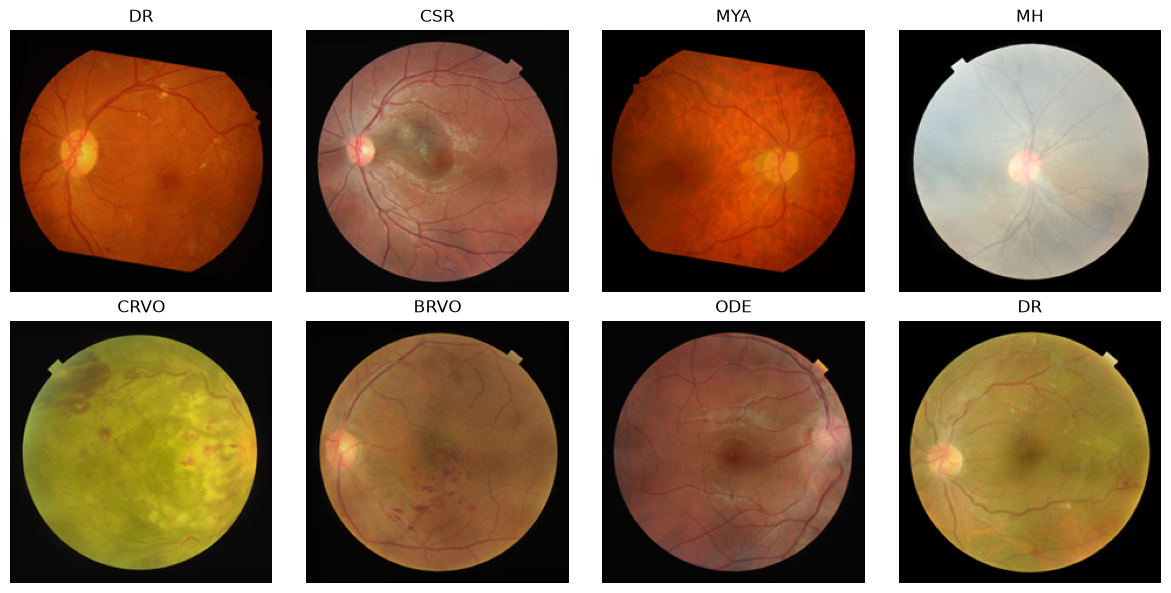

In [10]:
fig, axes = plt.subplots(2, 4, figsize=(12, 6))
for axis in axes.flat:
    axis.axis("off")
for axis, image, target in zip(axes.flat, train_images[:8], train_targets[:8]):
    picture = (image * std_tensor + mean_tensor).clamp(0, 1).permute(1, 2, 0).numpy()
    axis.imshow(picture)
    axis.set_title(class_names[int(target)])
plt.tight_layout()


## 11. Load ImageNet-pretrained Swin-Tiny

Use the official torchvision weights; the first run may download them. Replace the original classifier with an 11-output head using its actual input feature count.


In [11]:
weights = Swin_T_Weights.DEFAULT
model = swin_t(weights=weights)
print("Pretrained weights:", weights.name)
print("Original head:", model.head)
in_features = model.head.in_features
model.head = nn.Linear(in_features, num_classes)
model = model.to(device)
print("New head:", model.head)
print("Total parameters:", sum(parameter.numel() for parameter in model.parameters()))


Pretrained weights: IMAGENET1K_V1
Original head: Linear(in_features=768, out_features=1000, bias=True)
New head: Linear(in_features=768, out_features=11, bias=True)
Total parameters: 27527813


## 12. Freeze the backbone and prepare head training

Only the new classifier receives gradients for the first two epochs. The epoch function will keep the frozen backbone in evaluation mode, disabling its training-time randomness. CUDA AMP uses torch.autocast and torch.amp.GradScaler; both are disabled on CPU.


In [12]:
for parameter in model.parameters():
    parameter.requires_grad = False
for parameter in model.head.parameters():
    parameter.requires_grad = True
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.AdamW(model.head.parameters(), lr=HEAD_LR, weight_decay=WEIGHT_DECAY)
scaler = torch.amp.GradScaler("cuda", enabled=use_amp)
print("Trainable head parameters:", sum(p.numel() for p in model.parameters() if p.requires_grad))
print("Head learning rate:", HEAD_LR, "| weight decay:", WEIGHT_DECAY)
initial_head_state = {name: value.detach().clone() for name, value in model.head.state_dict().items()}


Trainable head parameters: 8459
Head learning rate: 0.0005 | weight decay: 0.0001


## 13. Train one epoch

Use the same short function for both stages. It changes model mode according to the stage, uses cross-entropy on raw logits, and averages loss by image count so the final smaller batch is handled correctly.


In [13]:
def train_one_epoch(loader, head_only):
    if head_only:
        model.eval()
        model.head.train()
    else:
        model.train()
    total_loss, correct, total = 0.0, 0, 0
    for images, targets in loader:
        images = images.to(device, non_blocking=use_amp)
        targets = targets.to(device, non_blocking=use_amp)
        optimizer.zero_grad(set_to_none=True)
        with torch.autocast(device_type=device.type, dtype=torch.float16, enabled=use_amp):
            logits = model(images)
            loss = criterion(logits, targets)
        if not torch.isfinite(loss):
            raise RuntimeError("Non-finite training loss; stop and inspect the batch.")
        scaler.scale(loss).backward()
        scaler.step(optimizer)
        scaler.update()
        total_loss += loss.item() * targets.size(0)
        correct += (logits.argmax(dim=1) == targets).sum().item()
        total += targets.size(0)
    return total_loss / total, correct / total

print("Training function ready for head-only and full fine-tuning stages.")


Training function ready for head-only and full fine-tuning stages.


## 14. Evaluate and calculate metrics

Evaluation disables gradients and returns loss, accuracy, predictions and true targets. A small metric function is reused for final validation and test reports, always including all 11 classes.


In [14]:
def evaluate(loader):
    model.eval()
    total_loss, correct, total = 0.0, 0, 0
    predictions, true_targets = [], []
    with torch.no_grad():
        for images, targets in loader:
            images = images.to(device, non_blocking=use_amp)
            targets = targets.to(device, non_blocking=use_amp)
            with torch.autocast(device_type=device.type, dtype=torch.float16, enabled=use_amp):
                logits = model(images)
                loss = criterion(logits, targets)
            if not torch.isfinite(loss):
                raise RuntimeError("Non-finite evaluation loss.")
            predicted = logits.argmax(dim=1)
            total_loss += loss.item() * targets.size(0)
            correct += (predicted == targets).sum().item()
            total += targets.size(0)
            predictions.extend(predicted.cpu().tolist())
            true_targets.extend(targets.cpu().tolist())
    return total_loss / total, correct / total, np.array(predictions), np.array(true_targets)

def classification_metrics(targets, predictions, loss):
    precision, recall, macro_f1, _ = precision_recall_fscore_support(
        targets, predictions, labels=LABELS, average="macro", zero_division=0)
    _, _, weighted_f1, _ = precision_recall_fscore_support(
        targets, predictions, labels=LABELS, average="weighted", zero_division=0)
    return {"loss": float(loss), "accuracy": float(accuracy_score(targets, predictions)),
            "macro_precision": float(precision), "macro_recall": float(recall),
            "macro_f1": float(macro_f1), "weighted_f1": float(weighted_f1)}

print("Evaluation and classification metric functions ready.")


Evaluation and classification metric functions ready.


## 15. Model and one-step sanity checks

Check the 11-output shape and finite loss on a training batch. Run one head update and verify that the head changes while a backbone parameter stays unchanged. The reset cell below removes this diagnostic update before the actual experiment.


In [15]:
model.eval()
with torch.no_grad():
    logits = model(train_images.to(device))
    sanity_loss = criterion(logits, train_targets.to(device))
assert logits.shape == (train_images.size(0), num_classes)
assert torch.isfinite(logits).all() and torch.isfinite(sanity_loss)
print("Output shape:", tuple(logits.shape), "| cross-entropy:", sanity_loss.item())

backbone_before = next(model.features.parameters()).detach().clone()
head_before = model.head.weight.detach().clone()
step_loss, step_accuracy = train_one_epoch([(train_images, train_targets)], head_only=True)
assert torch.equal(backbone_before, next(model.features.parameters()).detach())
assert not torch.equal(head_before, model.head.weight.detach())
assert all(p.grad is None for p in model.features.parameters())
assert all(torch.isfinite(p.grad).all() for p in model.head.parameters() if p.grad is not None)
print("Mini step passed: frozen backbone unchanged, classifier updated.")
print("Mini step loss:", step_loss, "| accuracy:", step_accuracy)
del backbone_before, head_before


Output shape: (16, 11) | cross-entropy: 2.3350918292999268
Mini step passed: frozen backbone unchanged, classifier updated.
Mini step loss: 2.334716796875 | accuracy: 0.25


## 16. Optional small loss-reduction check

Leave this disabled for a normal run. When enabled, repeat the same small training batch for a few head updates and inspect whether loss decreases. The following reset cell restores the original head before the 15-epoch run.


In [16]:
RUN_TINY_OVERFIT = False
if RUN_TINY_OVERFIT:
    tiny_losses = []
    for step in range(8):
        tiny_loss, _ = train_one_epoch([(train_images, train_targets)], head_only=True)
        tiny_losses.append(tiny_loss)
    print("Fixed training-batch losses:", [round(value, 4) for value in tiny_losses])
else:
    print("Optional small loss-reduction check skipped.")


Optional small loss-reduction check skipped.


## 17. Reset diagnostics before the experiment

Restore the original randomly initialized head and reset seeds, optimizer, scaler and shuffle generator. For a fresh experiment after full fine-tuning, rerun the notebook from the top so the model-loading cell also restores the pretrained backbone.


In [17]:
model.head.load_state_dict(initial_head_state)
model.zero_grad(set_to_none=True)
for parameter in model.parameters():
    parameter.requires_grad = False
for parameter in model.head.parameters():
    parameter.requires_grad = True
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
train_generator.manual_seed(SEED)
optimizer = torch.optim.AdamW(model.head.parameters(), lr=HEAD_LR, weight_decay=WEIGHT_DECAY)
scaler = torch.amp.GradScaler("cuda", enabled=use_amp)
history = []
best_val_macro_f1 = -1.0
best_epoch = None
training_finished = False
print("Diagnostics reset. Ready for the head stage.")


Diagnostics reset. Ready for the head stage.


## 18. Train both stages and save the best checkpoint

Epochs 1–2 train the head at 5e-4. At epoch 3, unfreeze every parameter and create a fresh AdamW optimizer at 5e-5, continuing from the head-stage weights. Select the best validation macro F1 across both stages and save history after every epoch.


In [18]:
for epoch in range(1, NUM_EPOCHS + 1):
    head_only = epoch <= HEAD_EPOCHS
    stage = "head" if head_only else "full"
    if epoch == HEAD_EPOCHS + 1:
        for parameter in model.parameters():
            parameter.requires_grad = True
        optimizer = torch.optim.AdamW(model.parameters(), lr=FINE_TUNE_LR, weight_decay=WEIGHT_DECAY)
        print("Unfroze all parameters. New AdamW learning rate:", FINE_TUNE_LR)

    train_loss, train_accuracy = train_one_epoch(train_loader, head_only=head_only)
    val_loss, val_accuracy, val_predictions, val_targets = evaluate(val_loader)
    val_macro_f1 = float(precision_recall_fscore_support(
        val_targets, val_predictions, labels=LABELS, average="macro", zero_division=0)[2])
    history.append({"epoch": epoch, "stage": stage, "learning_rate": optimizer.param_groups[0]["lr"],
                    "train_loss": train_loss, "train_accuracy": train_accuracy,
                    "val_loss": val_loss, "val_accuracy": val_accuracy, "val_macro_f1": val_macro_f1})
    print(f"Epoch {epoch}/{NUM_EPOCHS} [{stage}] | Train Loss: {train_loss:.4f} | Train Acc: {train_accuracy:.4f} | Val Loss: {val_loss:.4f} | Val Acc: {val_accuracy:.4f} | Val Macro F1: {val_macro_f1:.4f}")
    if val_macro_f1 > best_val_macro_f1:
        best_val_macro_f1 = val_macro_f1
        best_epoch = epoch
        torch.save({"model_state_dict": model.state_dict(), "optimizer_state_dict": optimizer.state_dict(),
                    "epoch": epoch, "stage": stage, "best_val_macro_f1": best_val_macro_f1,
                    "target_map": TARGET_MAP, "num_classes": num_classes}, CHECKPOINT_PATH)
        print("  Saved new best checkpoint:", CHECKPOINT_PATH.name)
    pd.DataFrame(history).to_csv(HISTORY_PATH, index=False)

training_finished = len(history) == NUM_EPOCHS
print("Epochs completed:", len(history), "| best epoch:", best_epoch, "| best validation macro F1:", best_val_macro_f1)


Epoch 1/15 [head] | Train Loss: 1.8687 | Train Acc: 0.4029 | Val Loss: 1.5951 | Val Acc: 0.4784 | Val Macro F1: 0.1675
  Saved new best checkpoint: best_swin_tiny.pth
Epoch 2/15 [head] | Train Loss: 1.4389 | Train Acc: 0.5609 | Val Loss: 1.3946 | Val Acc: 0.5935 | Val Macro F1: 0.3987
  Saved new best checkpoint: best_swin_tiny.pth
Unfroze all parameters. New AdamW learning rate: 5e-05
Epoch 3/15 [full] | Train Loss: 1.1120 | Train Acc: 0.6487 | Val Loss: 1.0268 | Val Acc: 0.6871 | Val Macro F1: 0.5552
  Saved new best checkpoint: best_swin_tiny.pth
Epoch 4/15 [full] | Train Loss: 0.7632 | Train Acc: 0.7464 | Val Loss: 0.7465 | Val Acc: 0.7554 | Val Macro F1: 0.6465
  Saved new best checkpoint: best_swin_tiny.pth
Epoch 5/15 [full] | Train Loss: 0.5469 | Train Acc: 0.8222 | Val Loss: 0.7471 | Val Acc: 0.7554 | Val Macro F1: 0.7018
  Saved new best checkpoint: best_swin_tiny.pth
Epoch 6/15 [full] | Train Loss: 0.4293 | Train Acc: 0.8749 | Val Loss: 0.7706 | Val Acc: 0.7554 | Val Macro F1

## 19. Plot learning curves

Plot losses, accuracies and validation macro F1 to inspect convergence and overfitting. The dotted line marks the switch from head training to full fine-tuning.


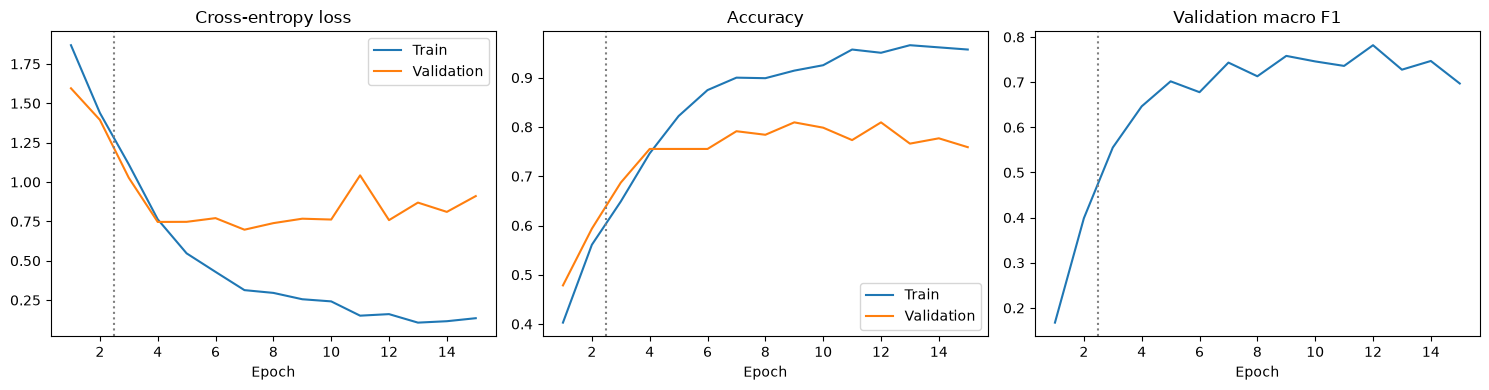

In [19]:
history_df = pd.DataFrame(history)
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
axes[0].plot(history_df["epoch"], history_df["train_loss"], label="Train")
axes[0].plot(history_df["epoch"], history_df["val_loss"], label="Validation")
axes[0].set_title("Cross-entropy loss")
axes[0].legend()
axes[1].plot(history_df["epoch"], history_df["train_accuracy"], label="Train")
axes[1].plot(history_df["epoch"], history_df["val_accuracy"], label="Validation")
axes[1].set_title("Accuracy")
axes[1].legend()
axes[2].plot(history_df["epoch"], history_df["val_macro_f1"])
axes[2].set_title("Validation macro F1")
for axis in axes:
    axis.set_xlabel("Epoch")
    axis.axvline(HEAD_EPOCHS + 0.5, color="gray", linestyle=":")
plt.tight_layout()


## 20. Reload the selected checkpoint

Restore the checkpoint with the highest validation macro F1, which may come from either stage. Verify its class mapping before evaluation.


In [20]:
assert training_finished, "Finish the training experiment before final evaluation."
checkpoint = torch.load(CHECKPOINT_PATH, map_location=device, weights_only=True)
assert checkpoint["target_map"] == TARGET_MAP
assert checkpoint["num_classes"] == num_classes
model.load_state_dict(checkpoint["model_state_dict"])
model.eval()
print("Selected epoch:", checkpoint["epoch"], "| stage:", checkpoint["stage"])
print("Selected validation macro F1:", checkpoint["best_val_macro_f1"])


Selected epoch: 12 | stage: full
Selected validation macro F1: 0.7818510714854547


## 21. Final validation results

Evaluate the selected weights on the complete validation set. Report macro metrics as well as accuracy because the disease counts are imbalanced.


In [21]:
val_loss, val_accuracy, val_predictions, val_targets = evaluate(val_loader)
validation_metrics = classification_metrics(val_targets, val_predictions, val_loss)
display(pd.Series(validation_metrics, name="Validation"))
print(classification_report(val_targets, val_predictions, labels=LABELS,
                            target_names=class_names, digits=4, zero_division=0))


loss               0.757930
accuracy           0.809353
macro_precision    0.787764
macro_recall       0.786281
macro_f1           0.781851
weighted_f1        0.810177
Name: Validation, dtype: float64

              precision    recall  f1-score   support

          DR     0.8295    0.9012    0.8639        81
          MH     0.9423    0.7903    0.8596        62
         ODC     0.7727    0.9444    0.8500        18
          DN     0.6562    0.6364    0.6462        33
        BRVO     0.4615    0.6000    0.5217        10
         ODE     1.0000    0.8571    0.9231        14
         MYA     1.0000    1.0000    1.0000        12
        ARMD     0.6667    0.5882    0.6250        17
          RS     0.8667    0.9286    0.8966        14
         CSR     0.6364    0.7778    0.7000         9
        CRVO     0.8333    0.6250    0.7143         8

    accuracy                         0.8094       278
   macro avg     0.7878    0.7863    0.7819       278
weighted avg     0.8189    0.8094    0.8102       278



## 22. One final test evaluation

Run this after model selection is complete. Evaluate the selected checkpoint once and reuse these predictions for the confusion matrix, per-class table and mistake inspection. Keep test results out of training decisions.


In [22]:
assert training_finished
test_loss, test_accuracy, test_predictions, test_targets = evaluate(test_loader)
test_metrics = classification_metrics(test_targets, test_predictions, test_loss)
display(pd.Series(test_metrics, name="Test"))
print(classification_report(test_targets, test_predictions, labels=LABELS,
                            target_names=class_names, digits=4, zero_division=0))


loss               0.750434
accuracy           0.835526
macro_precision    0.829459
macro_recall       0.800595
macro_f1           0.807356
weighted_f1        0.837413
Name: Test, dtype: float64

              precision    recall  f1-score   support

          DR     0.8902    0.9125    0.9012        80
          MH     0.9155    0.8904    0.9028        73
         ODC     0.6364    0.7778    0.7000        18
          DN     0.6061    0.6667    0.6349        30
        BRVO     0.7391    0.9444    0.8293        18
         ODE     1.0000    0.8000    0.8889        15
         MYA     1.0000    0.8824    0.9375        17
        ARMD     0.8667    0.7222    0.7879        18
          RS     1.0000    0.6429    0.7826        14
         CSR     0.6923    0.6923    0.6923        13
        CRVO     0.7778    0.8750    0.8235         8

    accuracy                         0.8355       304
   macro avg     0.8295    0.8006    0.8074       304
weighted avg     0.8481    0.8355    0.8374       304



## 23. Test confusion matrix

Rows are true diseases and columns are predictions. Both axes follow remapped Target order so they match the model outputs.


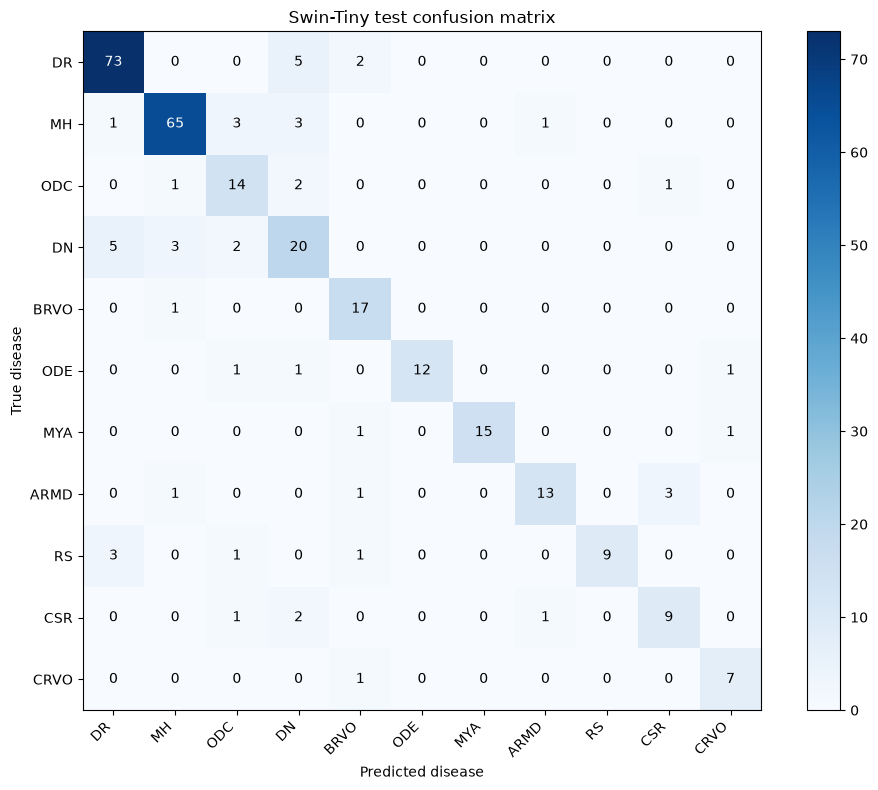

In [23]:
matrix = confusion_matrix(test_targets, test_predictions, labels=LABELS)
fig, axis = plt.subplots(figsize=(10, 8))
picture = axis.imshow(matrix, cmap="Blues")
fig.colorbar(picture, ax=axis)
axis.set_xticks(LABELS, class_names, rotation=45, ha="right")
axis.set_yticks(LABELS, class_names)
axis.set_xlabel("Predicted disease")
axis.set_ylabel("True disease")
axis.set_title("Swin-Tiny test confusion matrix")
for row in LABELS:
    for column in LABELS:
        axis.text(column, row, str(matrix[row, column]), ha="center", va="center",
                  color="white" if matrix[row, column] > matrix.max() / 2 else "black")
plt.tight_layout()


## 24. Per-class test results

Join precision, recall, F1 and support to the existing disease mapping. Sort numerically by the original Class_Index, while also displaying the Target used by the model.


In [24]:
precision, recall, f1, support = precision_recall_fscore_support(
    test_targets, test_predictions, labels=LABELS, average=None, zero_division=0)
per_class_results = class_table.assign(Support=support, Precision=precision, Recall=recall, F1=f1)
per_class_results = per_class_results.sort_values("Class_Index").reset_index(drop=True)
display(per_class_results[["Disease", "Class_Index", "Target", "Support", "Precision", "Recall", "F1"]])


,Disease,Class_Index,Target,Support,Precision,Recall,F1
0,DR,0,0,80,0.890244,0.912500,0.901235
1,ARMD,1,7,18,0.866667,0.722222,0.787879
2,MH,2,1,73,0.915493,0.890411,0.902778
3,DN,3,3,30,0.606061,0.666667,0.634921
4,MYA,4,6,17,1.000000,0.882353,0.937500
5,BRVO,5,4,18,0.739130,0.944444,0.829268
6,CSR,10,9,13,0.692308,0.692308,0.692308
7,ODC,11,2,18,0.636364,0.777778,0.700000
8,CRVO,12,10,8,0.777778,0.875000,0.823529
9,RS,13,8,14,1.000000,0.642857,0.782609


## 25. Optional inspection of wrong predictions

Display up to 12 misclassified test images using their deterministic transform. The model is not run again; titles use the saved predictions from the test evaluation.


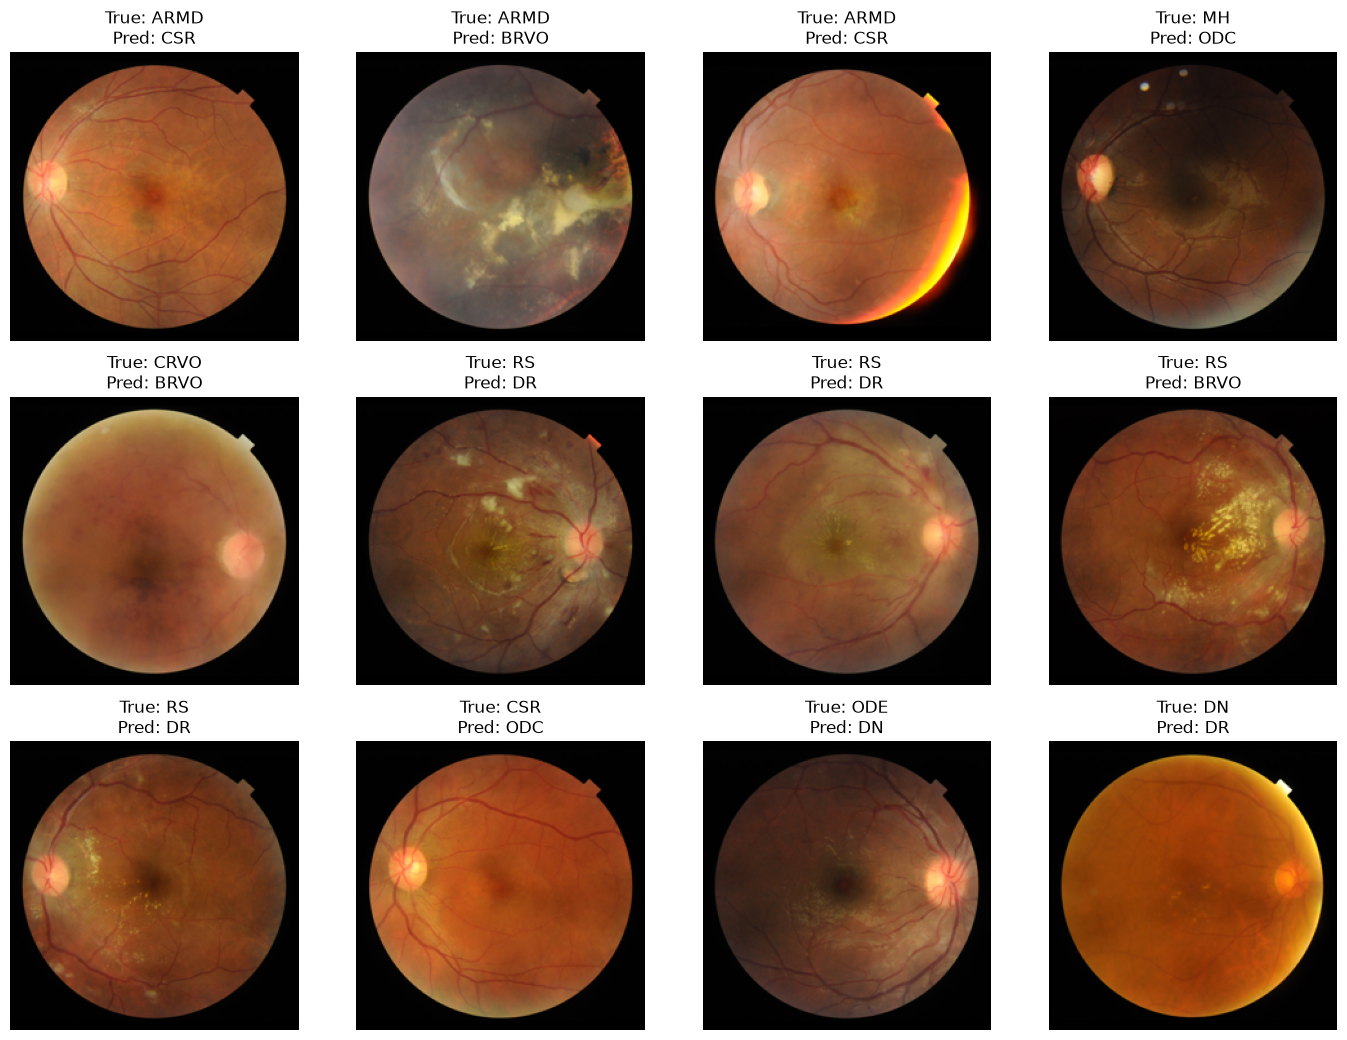

In [25]:
wrong_indices = np.flatnonzero(test_predictions != test_targets)[:12]
if len(wrong_indices) == 0:
    print("No misclassified test images.")
else:
    rows = (len(wrong_indices) + 3) // 4
    fig, axes = plt.subplots(rows, 4, figsize=(14, 3.5 * rows), squeeze=False)
    for axis in axes.flat:
        axis.axis("off")
    for axis, index in zip(axes.flat, wrong_indices):
        image, target = test_dataset[int(index)]
        picture = (image * std_tensor + mean_tensor).clamp(0, 1).permute(1, 2, 0).numpy()
        axis.imshow(picture)
        axis.set_title(f"True: {class_names[target]}\nPred: {class_names[int(test_predictions[index])]}")
    plt.tight_layout()


## 26. Save metrics and print the experiment summary

Save a small JSON with settings, class mapping and final metrics. The checkpoint and history CSV are already saved; report the chosen checkpoint rather than assuming the final epoch was best.


In [26]:
summary = {"model": "Swin-Tiny", "pretraining": weights.name, "num_classes": num_classes,
           "sample_counts": {split: int(counts[split]) for split in ["train", "val", "test"]},
           "input_size": [224, 224], "normalization_mean": MEAN, "normalization_std": STD,
           "loss": "CrossEntropyLoss", "optimizer": "AdamW", "weight_decay": WEIGHT_DECAY,
           "head_epochs": HEAD_EPOCHS, "head_learning_rate": HEAD_LR,
           "fine_tune_learning_rate": FINE_TUNE_LR, "batch_size": BATCH_SIZE,
           "epochs_trained": len(history), "seed": SEED, "device": str(device),
           "torch_version": str(torch.__version__), "torchvision_version": torchvision.__version__,
           "best_epoch": int(checkpoint["epoch"]), "best_stage": checkpoint["stage"],
           "best_validation_macro_f1": float(checkpoint["best_val_macro_f1"]),
           "target_map": TARGET_MAP, "validation_metrics": validation_metrics, "test_metrics": test_metrics}
with open(METRICS_PATH, "w", encoding="utf-8") as file:
    json.dump(summary, file, indent=2)
print("Model: Swin-Tiny | Pretraining:", weights.name, "| Classes:", num_classes)
print("Train / validation / test:", len(train_dataset), len(val_dataset), len(test_dataset))
print("Input: 224x224 | Loss: CrossEntropyLoss | Optimizer: AdamW | Batch:", BATCH_SIZE)
print("Head LR:", HEAD_LR, "| Full fine-tuning LR:", FINE_TUNE_LR, "| Epochs trained:", len(history))
print("Best epoch:", checkpoint["epoch"], "| Best validation macro F1:", checkpoint["best_val_macro_f1"])
for name, value in test_metrics.items():
    print(f"Final test {name}: {value:.4f}")
print("Saved:", CHECKPOINT_PATH.name, HISTORY_PATH.name, METRICS_PATH.name)


Model: Swin-Tiny | Pretraining: IMAGENET1K_V1 | Classes: 11
Train / validation / test: 911 278 304
Input: 224x224 | Loss: CrossEntropyLoss | Optimizer: AdamW | Batch: 16
Head LR: 0.0005 | Full fine-tuning LR: 5e-05 | Epochs trained: 15
Best epoch: 12 | Best validation macro F1: 0.7818510714854547
Final test loss: 0.7504
Final test accuracy: 0.8355
Final test macro_precision: 0.8295
Final test macro_recall: 0.8006
Final test macro_f1: 0.8074
Final test weighted_f1: 0.8374
Saved: best_swin_tiny.pth swin_tiny_history.csv swin_tiny_metrics.json
